In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv("zomato.csv", encoding='latin-1')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Checking number of rows and columns
print("Shape of dataset:", df.shape)

# Getting column names and data types
df.info()

# Statistical summary of numerical columns
df.describe()

# Checking missing values
df.isnull().sum()

Shape of dataset: (9551, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   objec

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [13]:
# Removing extra spaces from column names
df.columns = df.columns.str.strip()

# Converting all column names to lowercase for consistency
df.columns = df.columns.str.lower()

# Check again
print(df.columns)

Index(['restaurant id', 'restaurant name', 'country code', 'city', 'address',
       'locality', 'locality verbose', 'longitude', 'latitude', 'cuisines',
       'average cost for two', 'currency', 'has table booking',
       'has online delivery', 'is delivering now', 'switch to order menu',
       'price range', 'aggregate rating', 'rating color', 'rating text',
       'votes'],
      dtype='object')


In [16]:
# Filling missing values in cuisines
# Important because cuisine is key for analysis
df['cuisines'].fillna('Unknown', inplace=True)

# Drop unnecessary columns (they don't help in analysis)
df.drop(['restaurant id', 'address', 'locality verbose', 
         'longitude', 'latitude', 'switch to order menu'], axis=1, inplace=True)

# Check missing values again
df.isnull().sum()

C:\Users\au101\AppData\Local\Temp\ipykernel_5408\1742681662.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna('Unknown', inplace=True)


restaurant name         0
country code            0
city                    0
locality                0
cuisines                0
average cost for two    0
currency                0
has table booking       0
has online delivery     0
is delivering now       0
price range             0
aggregate rating        0
rating color            0
rating text             0
votes                   0
dtype: int64

In [17]:
# Extracting primary cuisine (first cuisine only)
# Example: "North Indian, Chinese" → "North Indian"
df['primary cuisine'] = df['cuisines'].apply(lambda x: x.split(',')[0])

# Convert Yes/No to numeric (helps in analysis)
df['has online delivery'] = df['has online delivery'].map({'Yes':1, 'No':0})
df['has table booking'] = df['has table booking'].map({'Yes':1, 'No':0})

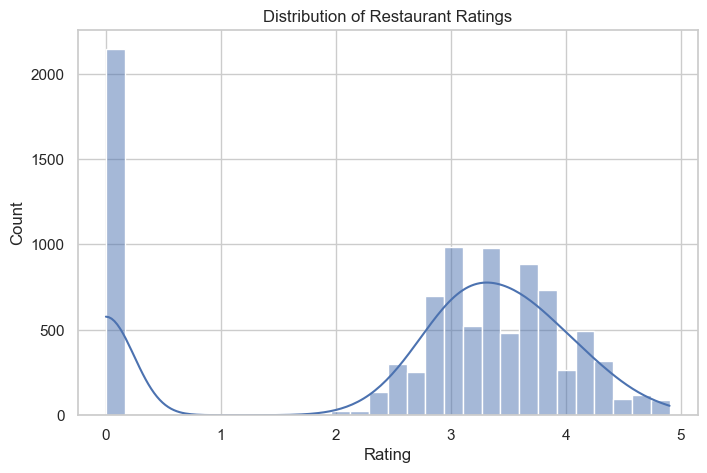

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['aggregate rating'], bins=30, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [19]:
#Most restaurants have ratings between 2.5 and 4.0, indicating moderate customer satisfaction.

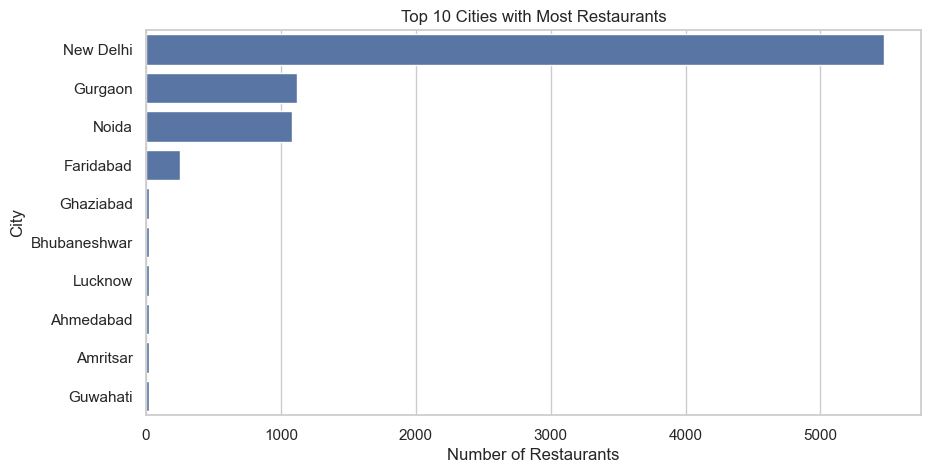

In [20]:
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

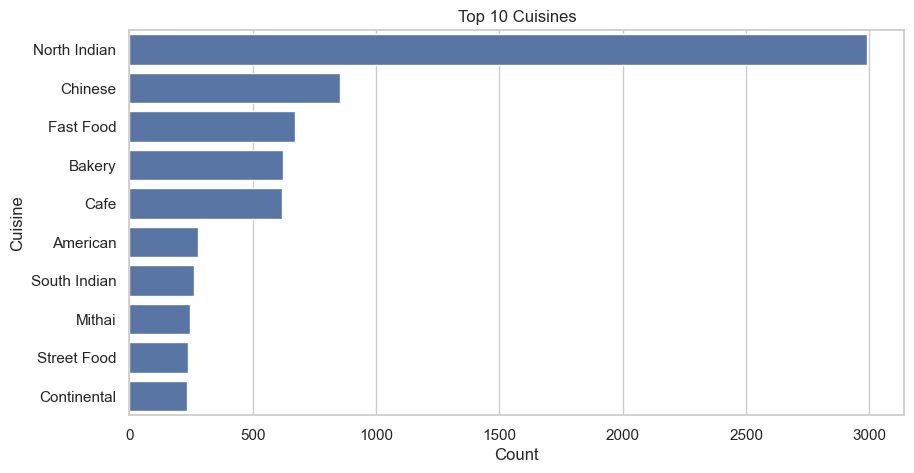

In [21]:
top_cuisines = df['primary cuisine'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

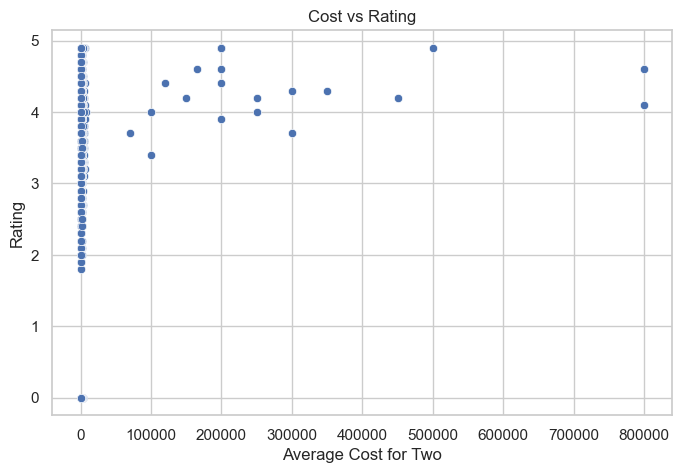

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='average cost for two', y='aggregate rating', data=df)

plt.title("Cost vs Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Rating")
plt.show()

In [23]:
#No strong relationship between cost and rating — expensive restaurants are not always better.

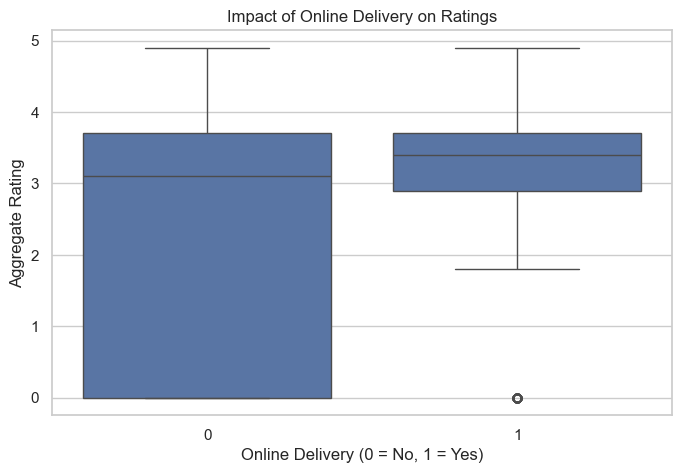

In [26]:
plt.figure(figsize=(8,5))

# Using boxplot to compare rating distribution across delivery availability
# WHY: helps understand if delivery changes customer satisfaction patterns
sns.boxplot(x='has online delivery', y='aggregate rating', data=df)

# Clear labeling improves readability for non-technical viewers
plt.title("Impact of Online Delivery on Ratings")
plt.xlabel("Online Delivery (0 = No, 1 = Yes)")
plt.ylabel("Aggregate Rating")

plt.show()

In [ ]:
#Insight: Online Delivery Impact

#- Restaurants offering online delivery tend to have slightly higher median ratings.
#- However, the difference is not very large, indicating delivery alone is not a strong factor.
#- Wider spread in ratings suggests customer experience varies even with delivery.


#Online delivery improves accessibility, but quality and service still drive ratings.

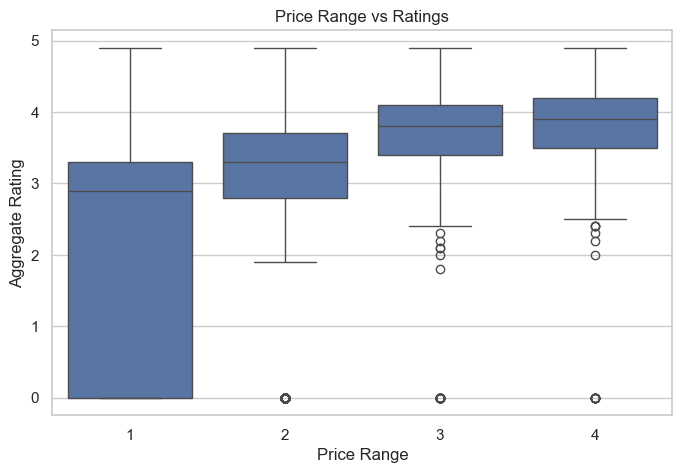

In [27]:
plt.figure(figsize=(8,5))

# Boxplot is used to compare how ratings vary across different price categories
# WHY: helps check if higher pricing leads to better perceived quality
sns.boxplot(x='price range', y='aggregate rating', data=df)

plt.title("Price Range vs Ratings")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")

plt.show()

In [34]:
#### Insight: Price Range vs Ratings

#- Ratings are fairly similar across all price ranges.
#- Higher-priced restaurants do not consistently receive better ratings.
#- Some low-cost restaurants perform equally well or better.


#Price does not guarantee quality — customer satisfaction depends more on experience than cost.

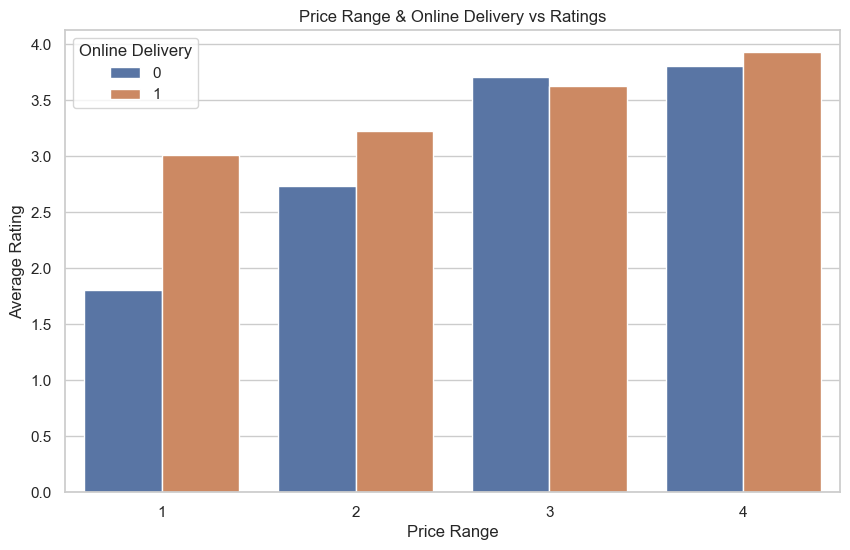

In [35]:
plt.figure(figsize=(10,6))

# WHY: analyzing interaction effect between price and delivery
# This helps understand combined influence instead of isolated factors
combo = df.groupby(['price range', 'has online delivery'])['aggregate rating'].mean().reset_index()

sns.barplot(x='price range', y='aggregate rating', hue='has online delivery', data=combo)

plt.title("Price Range & Online Delivery vs Ratings")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.legend(title="Online Delivery")

plt.show()

In [ ]:
#### Insight: Combined Analysis

#- Online delivery slightly improves ratings across all price ranges.
#- Mid-range restaurants with delivery perform the best overall.
#- High-end restaurants without delivery sometimes underperform.


#Combining affordability with convenience creates the best customer experience.

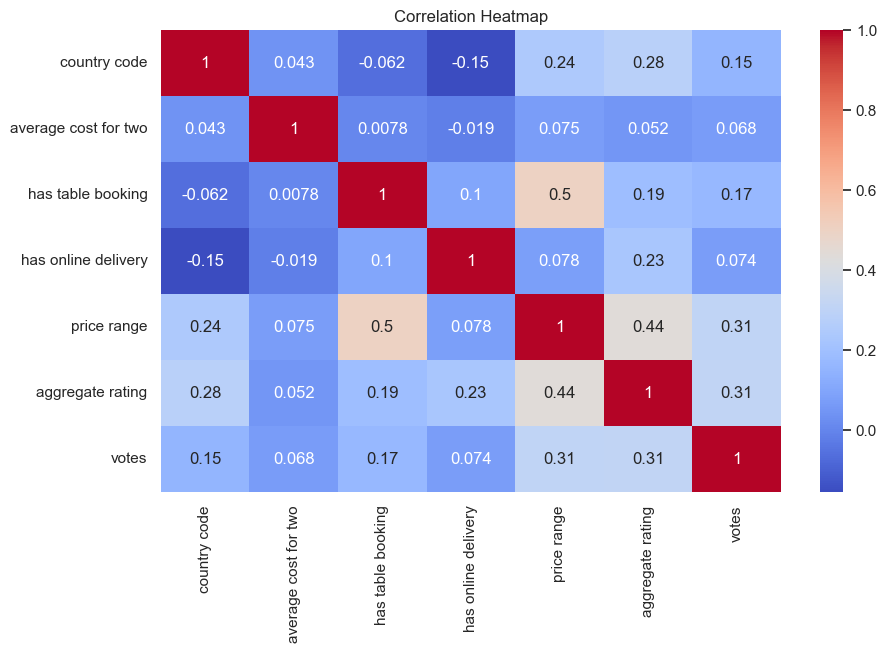

In [37]:
plt.figure(figsize=(10,6))

# WHY: identifying relationships between numerical features
# Helps detect hidden patterns not visible in individual plots
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#### Insight: Correlation Analysis

#- Weak correlation between cost and ratings.
# Votes may have slight positive relation with ratings.
#- Most variables are not strongly correlated.

#Restaurant success depends on multiple independent factors.

In [29]:
df['city'].value_counts().head(5)

city
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

In [30]:
df['primary cuisine'].value_counts().head(5)

primary cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
Name: count, dtype: int64

In [31]:
df.groupby('has online delivery')['aggregate rating'].mean()

has online delivery
0    2.465296
1    3.248837
Name: aggregate rating, dtype: float64

In [39]:
df.groupby('has table booking')['aggregate rating'].mean()

has table booking
0    2.559359
1    3.441969
Name: aggregate rating, dtype: float64

In [ ]:
### Final Business Recommendations

#- Focus on mid-range pricing for maximum customer satisfaction
# Enable online delivery to improve accessibility
#- Do not rely only on pricing to attract customers
#- Improve quality and service for better rating#s